In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import torch.distributions as dist
from scipy.spatial.distance import pdist
import plotly.graph_objects as go
#device = "cpu" #torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class SymmetryGAN:
    
    def __init__(self, dim, device="cpu", form="rot"):
        self.device = device
        self.data = None
        self.loader = None
        self.form = form
        self.dim = dim
        self.g = self.Generator(dim, form).to(device)
        self.d = self.Discriminator(dim).to(device)
        
    def insert_data(self, data, batch_size=128):
        self.data = data.to(self.device)
        self.loader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
        self.input_dim = len(data[0])
        
    class Discriminator(nn.Module):
    
        def __init__(self, input_dim):
            super().__init__()
            self.linear1 = nn.Linear(input_dim, 32)
            self.linear2 = nn.Linear(32, 64)
            self.linear3 = nn.Linear(64, 128)
            self.linear4 = nn.Linear(128, 64)
            self.linear5 = nn.Linear(64, 1)
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            x = F.relu(self.linear1(x))
            x = F.relu(self.linear2(x))
            x = F.relu(self.linear3(x))
            x = F.relu(self.linear4(x))
            x = self.sigmoid(self.linear5(x))
            return x
    
    class Generator(nn.Module):

        def __init__(self, dim, form):
            super().__init__()
            self.dim = dim
            self.form = form
            if form == "rot" or form == "ref":
                self.params = nn.Parameter(2 * torch.rand(dim ** 2) - 1.0)
                
        def matrix(self):
            g = torch.zeros((self.dim, self.dim))
            for i in range(self.dim):
                for j in range(self.dim):
                    g[i, j] = self.params[self.dim * i + j]
            return g
                
        def forward(self, x):
            g = torch.zeros((self.dim, self.dim))
            for i in range(self.dim):
                for j in range(self.dim):
                    g[i, j] = self.params[self.dim * i + j]
            return x @ g.t()
        
    def train(self, epochs=60, dlr=1e-3, glr=1e-3, print_losses=False, print_epochs=True, lambda_det=0, lambda_o=0):
        g_optim = optim.Adam(self.g.parameters(), lr=glr)
        d_optim = optim.Adam(self.d.parameters(), lr=dlr)
        param_history = []
        loss_history = []
        for epoch in range(1, epochs + 1):                                 
            for x in self.loader: 

                # train discriminator
                d_optim.zero_grad()
                g_x = self.g(x.detach())
                d_x = self.d(x)
                d_g_x = self.d(g_x.detach())
                loss_d = -torch.mean(torch.log(d_x + 1e-8) + torch.log(1 - d_g_x + 1e-8))
                loss_d.backward()
                d_optim.step()

                # generator loss
                g_optim.zero_grad()
                g_x = self.g(x)
                d_g_x = self.d(g_x)
                loss_g = -torch.mean(torch.log(d_g_x + 1e-8))
                
                # determinent loss
                m = self.g.matrix()
                loss_det = 0
                if self.form == "rot":
                    loss_det = lambda_det * (torch.linalg.det(m) - 1) ** 2
                elif self.form == "ref":
                    loss_det = lambda_det * (torch.linalg.det(m) + 1) ** 2
                
                # orthogonality loss
                loss_o = lambda_o * torch.sum((m.t() @ m - torch.eye(self.dim, device=self.device))**2)
    
                # train generator
                loss_total = loss_g + loss_det + loss_o
                loss_total.backward()
                g_optim.step()
                loss_history.append([loss_d, loss_g, loss_det, loss_o])
                param_history.append(self.g.params.detach().clone())
            if print_losses:
                print(f"\nEpoch {epoch} | D loss: {loss_d:.4f} | G loss: {loss_g:.4f} | Det Loss: {loss_det:.4f} | Ortho Loss: {loss_o:.4f}")
            elif print_epochs:
                if epochs < 15:
                    print(f"Epoch {epoch}")
                elif epochs < 30 and epoch % 5 == 0:
                    print(f"Epoch {epoch}")
                elif epoch % 10 == 0:
                    print(f"Epoch {epoch}")
        print("Training Complete")
        return param_history, loss_history

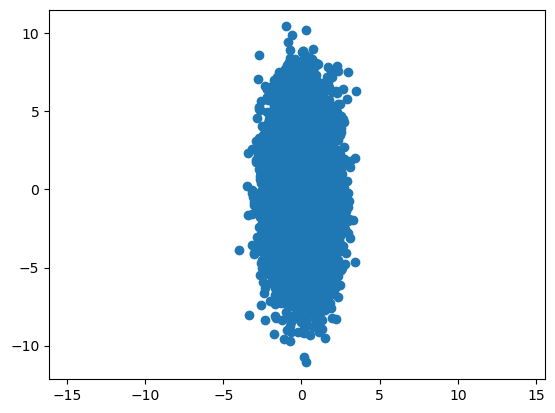

In [13]:
data = torch.randn(10_000, 2) @ torch.tensor([[1.0, 0.0], [0.0, 3.0]])
plt.scatter(data[:,0], data[:,1])
plt.axis("equal")
plt.show()

In [20]:
model = SymmetryGAN(2)
model.insert_data(data)
params, losses = model.train(epochs=30, lambda_det=5, lambda_o=5, print_losses=True)
R = model.g.matrix().detach().numpy()
np.arctan2(R[1, 0], R[0, 0]).round(decimals=2)


Epoch 1 | D loss: 0.2593 | G loss: 2.7872 | Det Loss: 5.5208 | Ortho Loss: 5.8391

Epoch 2 | D loss: 0.1881 | G loss: 2.6236 | Det Loss: 5.9968 | Ortho Loss: 5.3043

Epoch 3 | D loss: 0.1346 | G loss: 2.9752 | Det Loss: 5.7192 | Ortho Loss: 5.1502

Epoch 4 | D loss: 0.2688 | G loss: 3.1401 | Det Loss: 5.9674 | Ortho Loss: 4.9760

Epoch 5 | D loss: 0.2215 | G loss: 2.4846 | Det Loss: 5.8034 | Ortho Loss: 4.9655

Epoch 6 | D loss: 0.2351 | G loss: 2.5926 | Det Loss: 5.8433 | Ortho Loss: 4.9461

Epoch 7 | D loss: 0.4362 | G loss: 2.4353 | Det Loss: 5.7476 | Ortho Loss: 4.9556

Epoch 8 | D loss: 0.2796 | G loss: 2.7949 | Det Loss: 5.6952 | Ortho Loss: 4.9587

Epoch 9 | D loss: 0.5463 | G loss: 2.8636 | Det Loss: 5.6955 | Ortho Loss: 4.9573

Epoch 10 | D loss: 0.2744 | G loss: 2.6408 | Det Loss: 5.6617 | Ortho Loss: 4.9611

Epoch 11 | D loss: 0.5832 | G loss: 2.4374 | Det Loss: 5.5701 | Ortho Loss: 4.9710

Epoch 12 | D loss: 0.4865 | G loss: 2.2867 | Det Loss: 5.6469 | Ortho Loss: 4.9617



1.54

In [16]:
angles = []

In [17]:
for i in range(10):
    model = SymmetryGAN(2)
    model.insert_data(data)
    params, losses = model.train(epochs=30, lambda_det=2, lambda_o=2, print_epochs=False)
    R = model.g.matrix().detach().numpy()
    theta = np.arctan2(R[1, 0], R[0, 0])
    angles.append(theta)

Training Complete
Training Complete
Training Complete
Training Complete
Training Complete
Training Complete
Training Complete
Training Complete
Training Complete
Training Complete


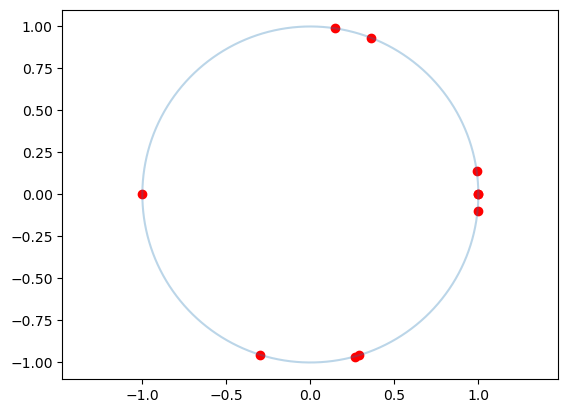

In [18]:
t = np.linspace(0, 2*np.pi, 10_000)
plt.plot(np.cos(t), np.sin(t), alpha=0.3)
plt.axis('equal')
for theta in angles:
    plt.scatter(np.cos(theta), np.sin(theta), c="red")
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axis("equal")
plt.show()

In [202]:
reflections = []
matrices = []

In [206]:
for i in range(10):
    model = SymmetryGAN(2, form="ref")
    model.insert_data(data)
    params, losses = model.train(epochs=40, lambda_det=2, lambda_o=2, print_epochs=False)
    R = model.g.matrix().detach().numpy()
    w, V = np.linalg.eig(R)
    w = np.real(w)
    V = np.real(V)
    i = np.argmin(np.abs(w - 1.0))
    a = V[:, i]
    a = a / np.linalg.norm(a)
    reflections.append(a)
    matrices.append(R)

Training Complete
Training Complete
Training Complete
Training Complete
Training Complete
Training Complete
Training Complete
Training Complete
Training Complete
Training Complete


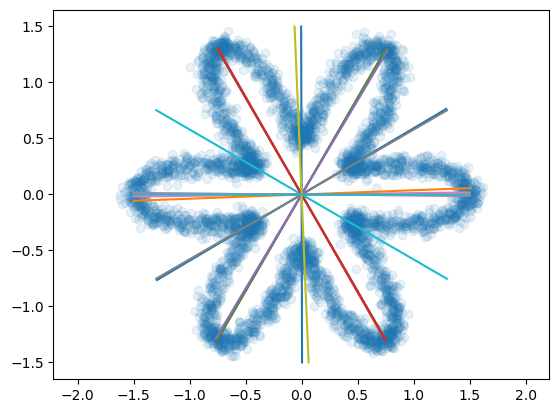

In [207]:
for a in reflections:
    plt.plot([-1.5 * a[0], 1.5 * a[0]], [-1.5 * a[1], 1.5 * a[1]])
plt.xlim(-1.7, 1.7)
plt.ylim(-1.7, 1.7)
plt.axis('equal')
plt.scatter(data[:, 0], data[:, 1], alpha=0.1)
plt.show()